In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df  = pd.read_csv('https://raw.githubusercontent.com/Krishnadevyadav1/SPAM_DETECTOR/refs/heads/main/spam.tsv', 
sep='\t',on_bad_lines='skip')
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


In [6]:
df.isnull().sum()

label      0
message    0
length     0
punct      0
dtype: int64

In [7]:
df.shape

(11139, 4)

In [8]:
df['label'].value_counts()

label
ham     9646
spam    1493
Name: count, dtype: int64

In [9]:
ham = df[df['label']=='ham']
ham.shape

(9646, 4)

In [10]:
spam = df[df['label']=='spam']
spam.shape

(1493, 4)

In [11]:
ham = ham.sample(spam.shape[0])

In [12]:
ham.shape


(1493, 4)

In [13]:
data = pd.concat([ham, spam], axis=0, ignore_index=True)

In [14]:
data.shape

(2986, 4)

In [15]:
data.sample(5)

,label,message,length,punct
805,ham,"Aight, text me tonight and we'll see what's up",46,3
246,ham,"Aight, I'll ask a few of my roommates",37,2
1062,ham,For real tho this sucks. I can't even cook my ...,87,5
2944,spam,Had your mobile 11mths ? Update for FREE to Or...,160,3
2547,spam,You have WON a guaranteed Ã¥Â£1000 cash or a Ã...,156,2


In [16]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (10, 4)
plt.style.use('ggplot')

In [17]:
ham.columns

Index(['label', 'message', 'length', 'punct'], dtype='object')

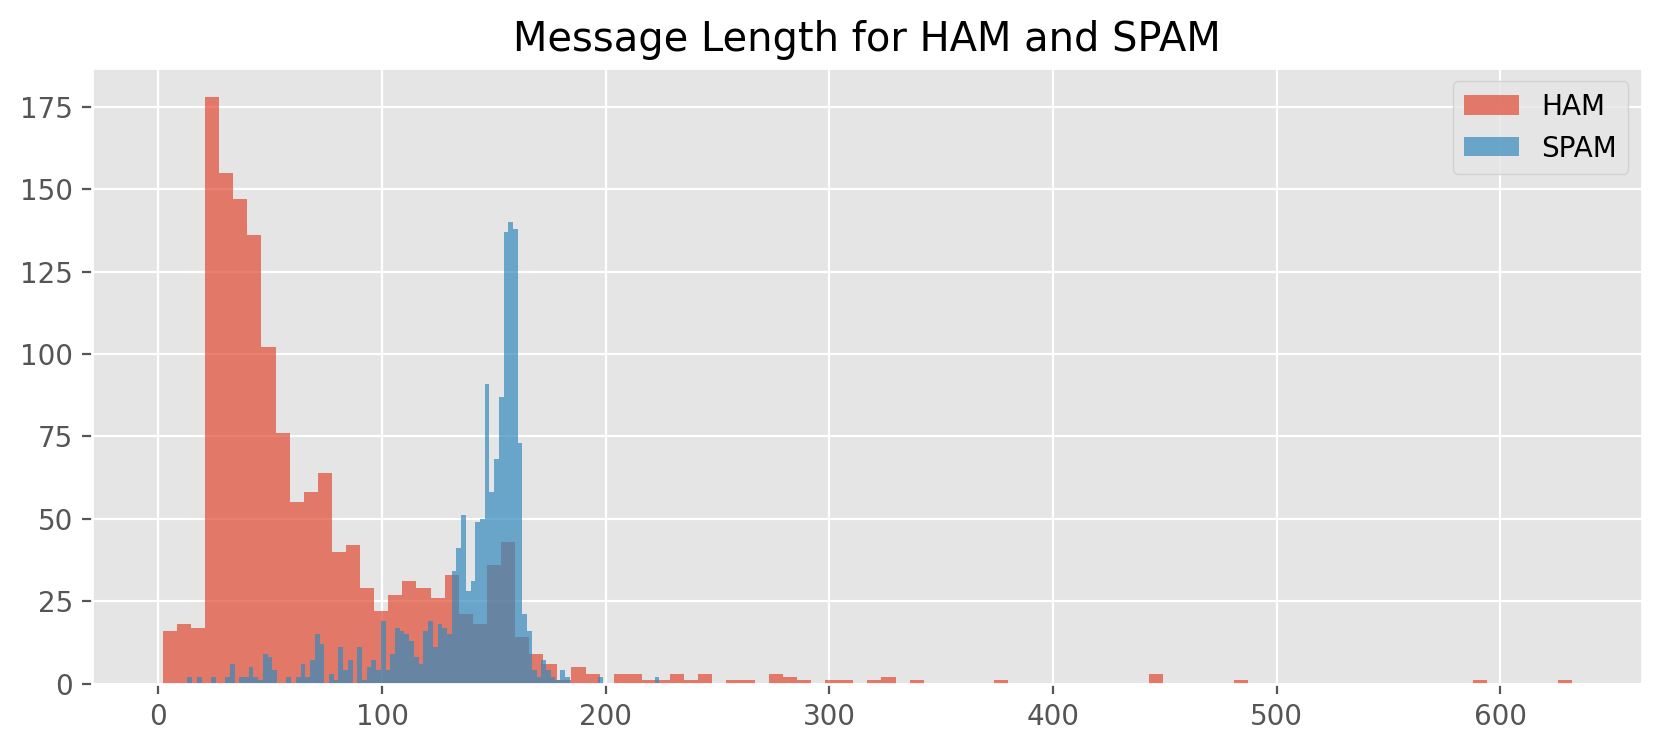

In [18]:
plt.hist(ham['length'], bins=100, alpha=0.7, label='HAM')
plt.hist(spam['length'], bins=100, alpha=0.7, label='SPAM')
plt.title('Message Length for HAM and SPAM')
plt.legend()
plt.show()

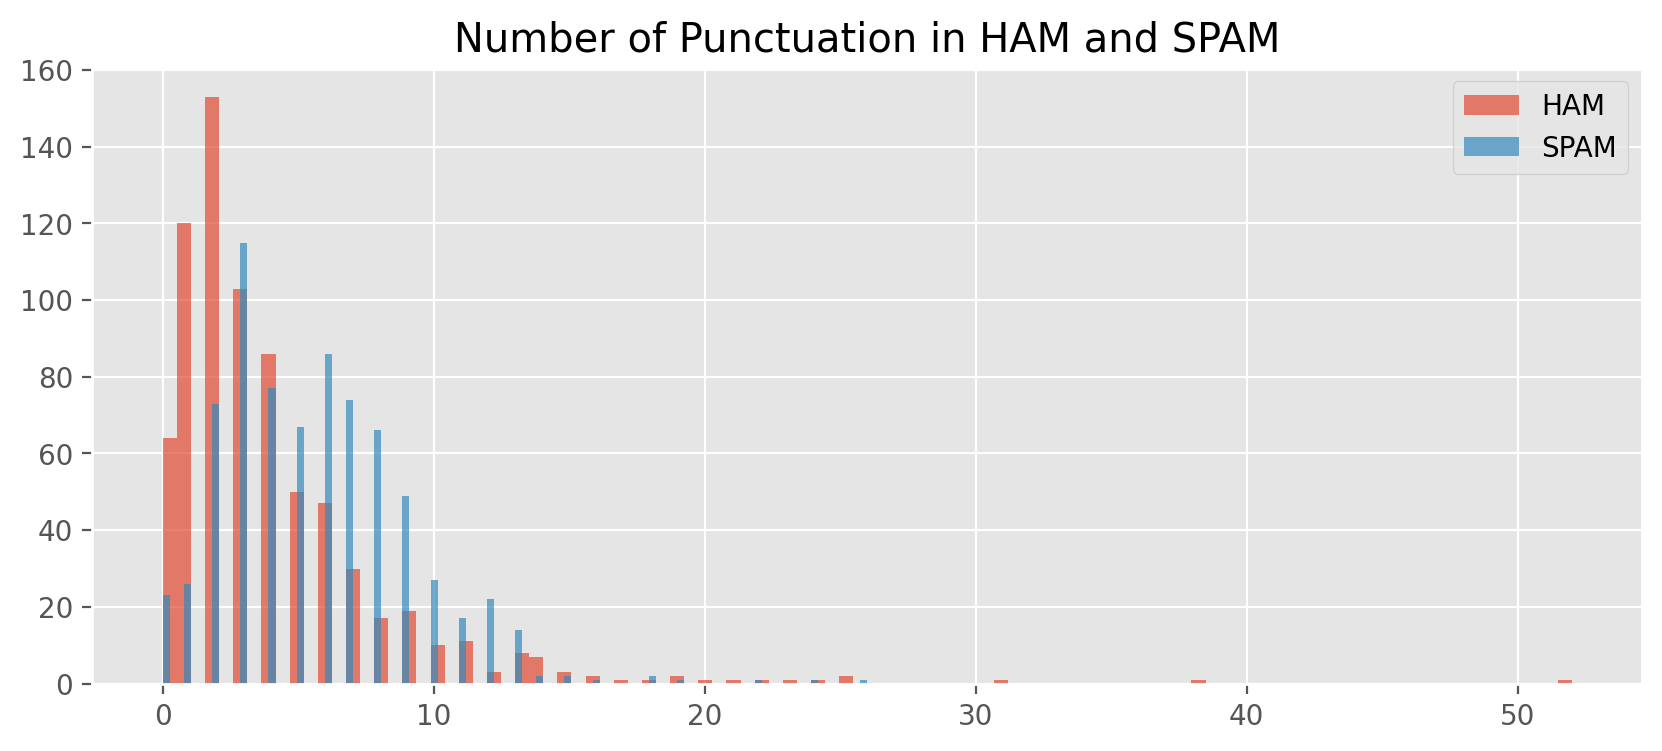

In [22]:
plt.hist(ham['punct'], bins=100, alpha=0.7, label='HAM')
plt.hist(spam['punct'], bins=100, alpha=0.7, label='SPAM')
plt.title('Number of Punctuation in HAM and SPAM')
plt.legend()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

In [20]:
X_train, X_test, y_train, y_test = train_test_split(data['message'], data['label'],
                                                   test_size=0.2, random_state=0,
                                                   shuffle=True, stratify=data['label'])

X_train.shape, X_test.shape

((2388,), (598,))

In [21]:
clf = Pipeline([('tfidf', TfidfVectorizer()), 
                ('rfc', RandomForestClassifier(n_estimators=100, n_jobs=-1))])

clf.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('rfc', RandomForestClassifier(n_jobs=-1))])

In [23]:
y_pred = clf.predict(X_test)

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       299
        spam       1.00      0.99      0.99       299

    accuracy                           0.99       598
   macro avg       1.00      0.99      0.99       598
weighted avg       1.00      0.99      0.99       598



In [25]:
clf.predict(['you have won lottery ticket worth $1000, please click here to claim',
            'hi, how are you doing today?'])



array(['spam', 'ham'], dtype=object)

In [26]:
clf.classes_

array(['ham', 'spam'], dtype=object)

In [27]:
import pickle

pickle.dump(clf, open('model.pkl', 'wb'))


In [28]:
model = pickle.load(open('model.pkl', 'rb'))

In [31]:
model.predict(['you have won lottery ticket worth $1000, please click here to claim'])


array(['spam'], dtype=object)